Import Library

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
import seaborn as sns
from sklearn.metrics import confusion_matrix

Load dataset

In [2]:
data = pd.read_csv('Churn_Modelling.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Droping unnecessary colums

In [3]:
data.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

Encoding categorical variables

In [4]:
data['Gender'] = data['Gender'].replace({'Male': 0, 'Female': 1})
data['Geography'] = data['Geography'].replace({'France': 0, 'Germany': 1, 'Spain': 2})


Splitting the dataset into features and target variable

In [5]:
X = data.drop('Exited', axis=1)
y = data['Exited']


Splitting the data into training and testing sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Scaling the features

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Building the Sequential model

In [ ]:
model = Sequential()
model.add(Dense(units=64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

Compiling the model

In [9]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Training the model

In [10]:
history = model.fit(X_train, y_train, epochs=10, batch_size=10, validation_split=0.2)



Epoch 1/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8078 - loss: 0.4746 - val_accuracy: 0.8419 - val_loss: 0.3936
Epoch 2/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8358 - loss: 0.3899 - val_accuracy: 0.8550 - val_loss: 0.3603
Epoch 3/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8572 - loss: 0.3526 - val_accuracy: 0.8506 - val_loss: 0.3508
Epoch 4/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8694 - loss: 0.3275 - val_accuracy: 0.8381 - val_loss: 0.3509
Epoch 5/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8577 - loss: 0.3391 - val_accuracy: 0.8462 - val_loss: 0.3481
Epoch 6/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8612 - loss: 0.3317 - val_accuracy: 0.8506 - val_loss: 0.3457
Epoch 7/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8619 - loss: 0.3294 - val_accuracy: 0.8487 - val_loss: 0.3434
Epoch 8/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8637 - loss: 0.3263 - val_accuracy: 0.

Making predictions on the test set

In [11]:
predictions = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Converting probabilities to binary predictions

In [12]:
threshold = 0.5
binary_predictions = (predictions > threshold).astype(int)

Computing confusion matrix

In [13]:
conf_matrix = confusion_matrix(y_test, binary_predictions)

Plotting confusion matrix

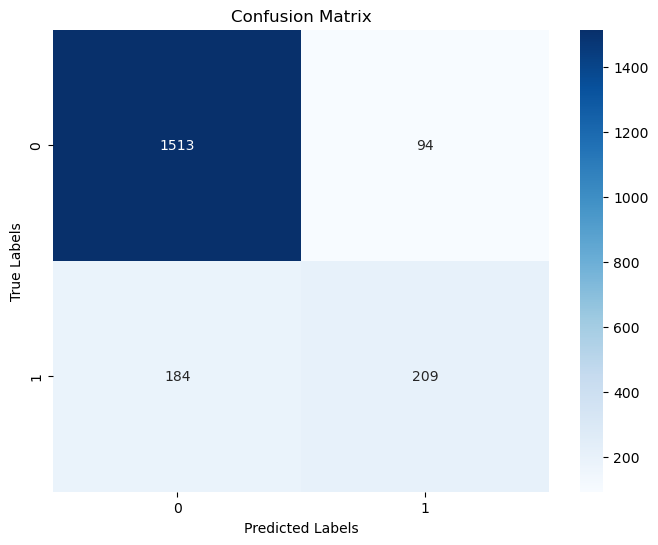

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Evaluating the model

In [15]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy}')


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8597 - loss: 0.3478
Test Accuracy: 0.8610000014305115


Extracting loss and accuracy from the history object

In [16]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(train_loss) + 1)


Plotting training and validation loss

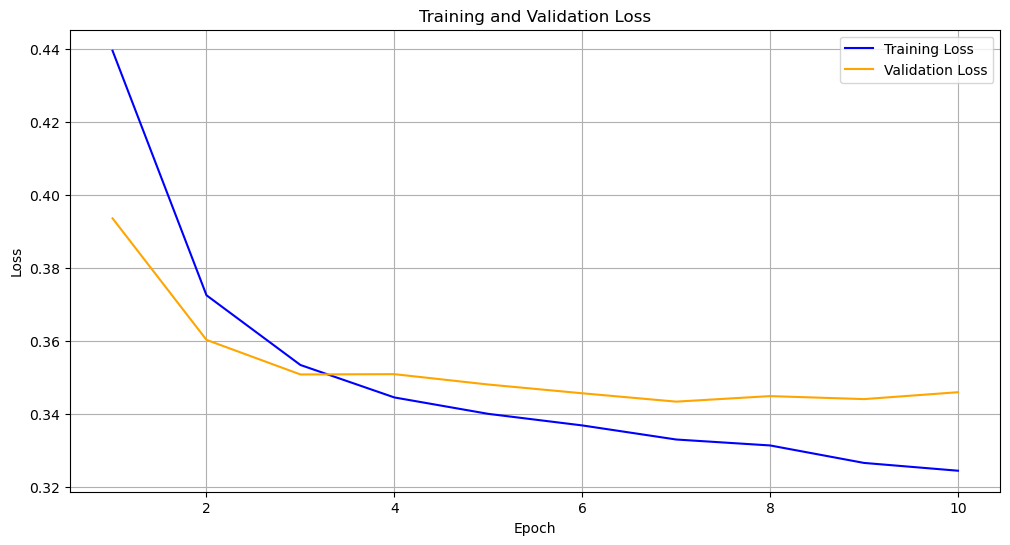

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_loss, label='Training Loss', color='blue')
plt.plot(epochs, val_loss, label='Validation Loss', color='orange')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


Plotting training and validation accuracy

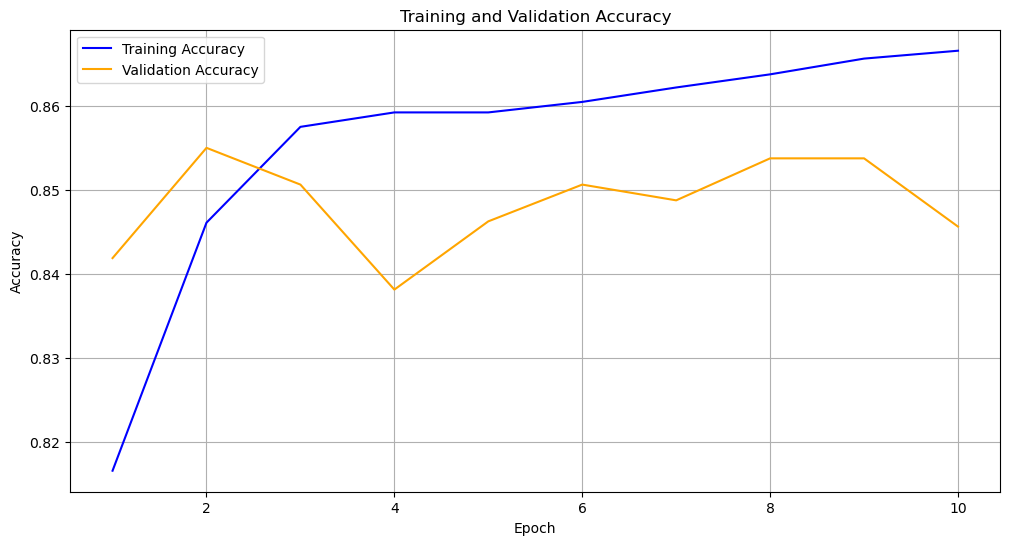

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_accuracy, label='Training Accuracy', color='blue')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()